             ******** LIFE EXPECTANCY PREDICTION *******

**IMPORT LIBRARIES**

In [191]:
# Standard library imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

**LOAD DATA**

In [192]:
df = pd.read_csv("Life Expectancy Data.csv")    # LOAD DATA
df.columns = df.columns.str.strip()         # Clean column names

print(df.shape)
df.head()
df.info()

(2938, 22)
<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

Life Expectancy dataset is a real-world, meaningful dataset that helps analyze how different health, economic, and social factors affect human life expectancy across countries.

**BASIC DATA UNDERSTANDING**


In [213]:
print("\nStatistical Summary:\n")
print(df.describe())
print("\nMissing Values:",df.isnull().sum())        # CHECK MISSING VALUES
print("\nDuplicate Rows:", df.duplicated().sum())


Statistical Summary:

            Status  Life expectancy  Adult Mortality  infant deaths  \
count  2928.000000      2928.000000      2928.000000    2928.000000   
mean      0.825137        69.224932       164.796448      30.407445   
std       0.379915         9.523867       124.292079     118.114450   
min       0.000000        36.300000         1.000000       0.000000   
25%       1.000000        63.100000        74.000000       0.000000   
50%       1.000000        72.100000       144.000000       3.000000   
75%       1.000000        75.700000       228.000000      22.000000   
max       1.000000        89.000000       723.000000    1800.000000   

           Alcohol  percentage expenditure  Hepatitis B        Measles  \
count  2735.000000             2928.000000  2375.000000    2928.000000   
mean      4.614856              740.321185    80.960842    2427.855874   
std       4.050749             1990.930605    25.018337   11485.970937   
min       0.010000                0.00000

We observe that some features like **Population, GDP, and Hepatitis B** have a high number of missing values, so proper imputation or handling is required before model building.

- Life expectancy ranges from **36 to 89 years**, showing strong variation across countries.
- High standard deviation in **GDP, population, and mortality features** indicates large global differences.
- Many health indicators like **Hepatitis B and Alcohol consumption** vary significantly, affecting life expectancy.
- There are **no duplicate values** in dataset.

**TARGET VARIABLE ANALYSIS**

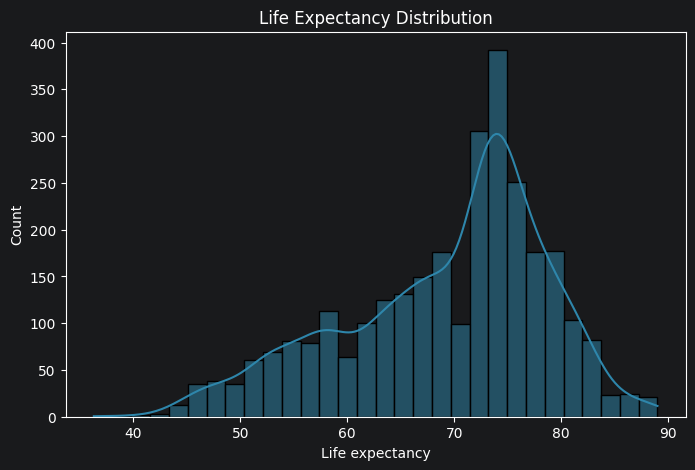

In [194]:
# LIFE EXPECTANCY DISTRIBUTION

plt.figure(figsize=(8,5))

sns.histplot(df["Life expectancy"], kde=True, color="#2E86AB")

plt.title("Life Expectancy Distribution")

plt.show()

The histogram shows the distribution of global life expectancy, ranging from about 40 to 90 years. Most values are concentrated between **70 and 80 years**, indicating that this is the most common life expectancy range in the dataset.

The distribution is **slightly left-skewed**, meaning fewer countries/regions have very low life expectancy, while most fall in the higher range. Overall, the chart highlights that globally, people tend to live longer in most regions, with only a small portion experiencing low life expectancy.


**CORRELATION ANALYSIS**

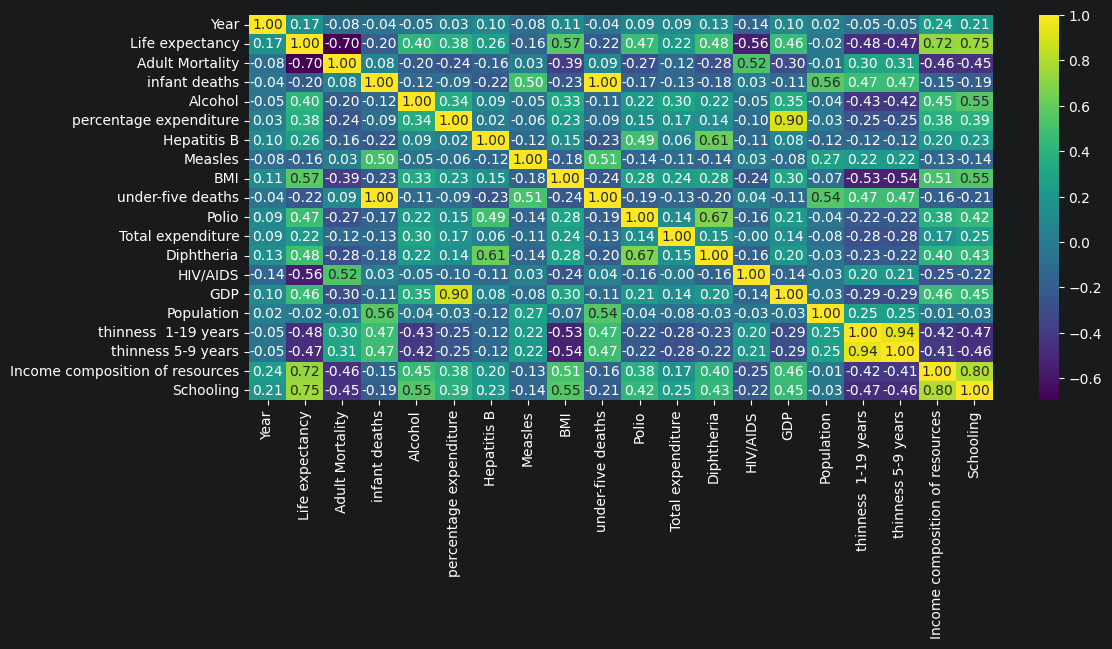

In [195]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="viridis")
plt.show()

- **Features that increase Life Expectancy:**
Schooling (0.75),
GDP (0.46),
Income composition of resources (0.72),
Polio / Diphtheria (-0.4–0.5),
BMI (0.57),
Health expenditure (-0.38)

- **Features that reduce Life Expectancy:**
Adult Mortality (-0.70),
HIV/AIDS (-0.56),
Infant deaths (-0.20),
Under-five deaths (-0.22),
Measles

 - **Multicollinearity:**
Infant deaths ↔ Under-five deaths (1.00),
thinness 1–19 ↔ Thinness 5–9 (0.94),
GDP ↔ Percentage expenditure (0.90),
Schooling ↔ Income composition (0.80) --- Remove one from each pair to avoid redundancy

**EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATION**

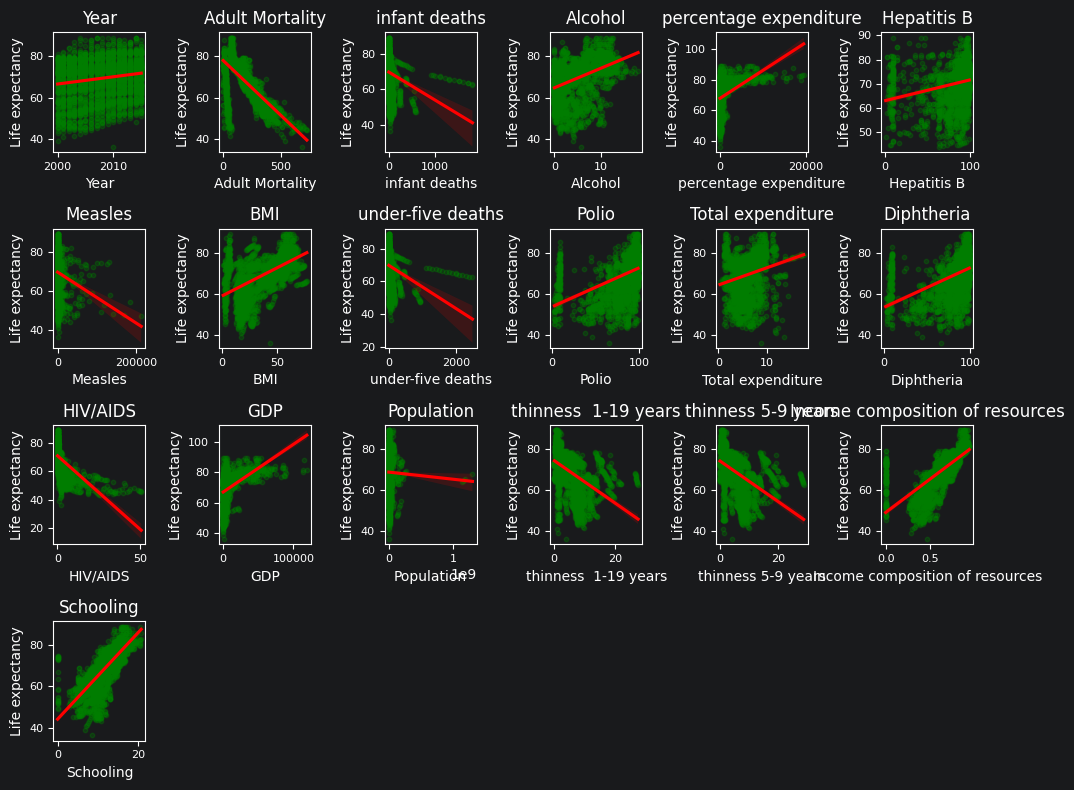

In [196]:
target = 'Life expectancy'

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
features = [col for col in numeric_cols if col != target]

n_cols = 6  # small grid width
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2*n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.regplot(
        x=df[col],
        y=df[target],
        ax=axes[i],
        scatter_kws={'alpha': 0.3, 's': 10, 'color': 'green'},
        line_kws={'color': 'red'}
    )
    axes[i].set_title(col)
    axes[i].tick_params(labelsize=8)

# remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- **Positive patterns:** Schooling, GDP, BMI, Polio, Diphtheria, Hepatitis B
- **Negative patterns:** Adult Mortality, HIV/AIDS, Infant deaths, Under-five deaths
- **Weak or unclear patterns:** Population, Year, Total expenditure
- **Mixed / non-linear patterns:** Alcohol, Percentage expenditure, Thinness 1–19 years
- **Outliers observed in:** GDP, HIV/AIDS, Adult Mortality, Infant deaths

**LIFE EXPECTANCY VS COUNTRY STATUS VISUALIZATION**

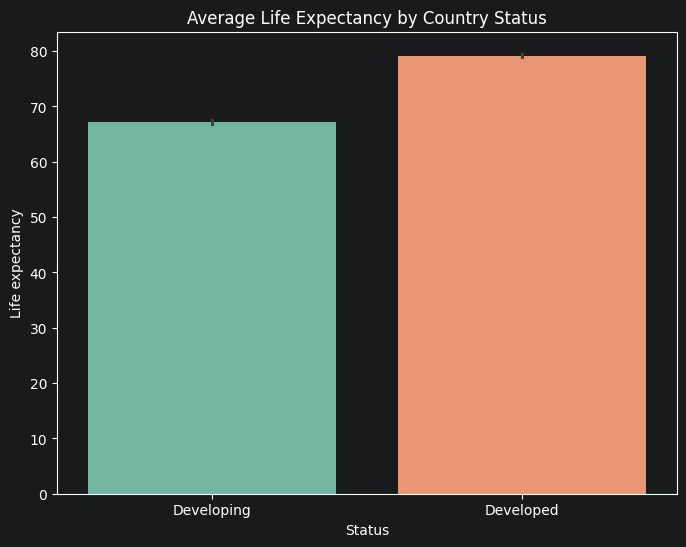

In [197]:
# Relationship
plt.figure(figsize=(8,6))

sns.barplot(
    x='Status',
    y='Life expectancy',
    data=df,
    hue='Status',
    palette="Set2",
    legend=False
)

plt.title('Average Life Expectancy by Country Status')
plt.show()

Developed countries have higher average life expectancy,
Developing countries have lower average life expectancy

**BOX PLOT ANALYSIS – OUTLIER DETECTION (EDA)**

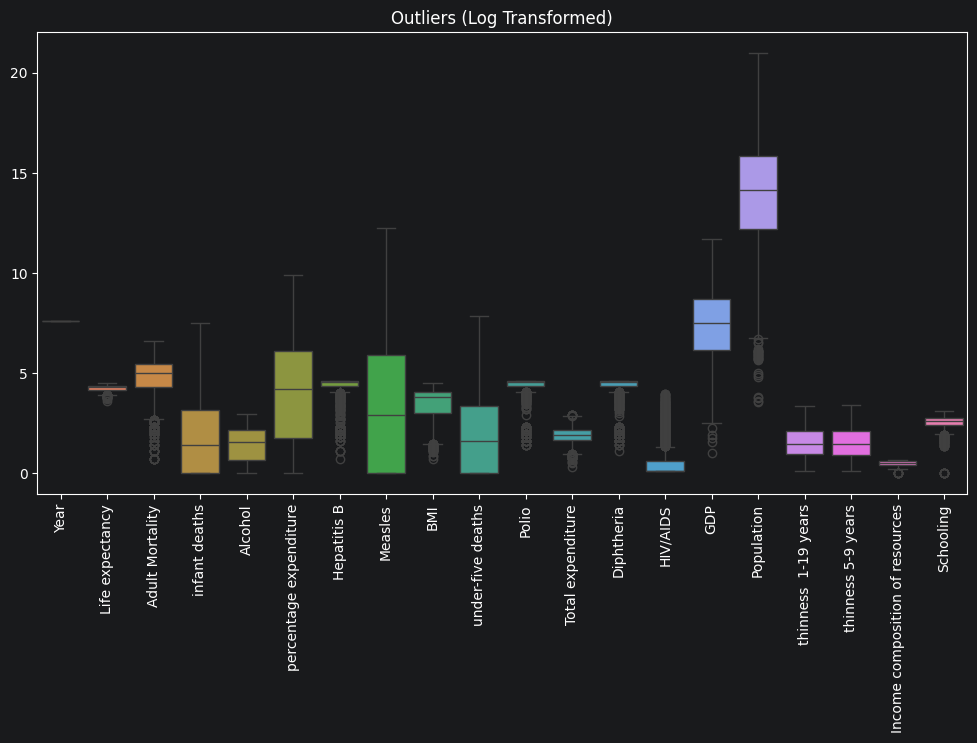

In [198]:
df_log = np.log1p(df.select_dtypes(include=np.number))
plt.figure(figsize=(12,6))
sns.boxplot(data=df_log)
plt.xticks(rotation=90)
plt.title("Outliers (Log Transformed)")
plt.show()

The boxplot shows the distribution of different numerical features before data cleaning. Most variables are fairly consistent, but some features contain significant outliers.

The **Population** column shows extremely large outliers compared to all other variables, indicating high variation across countries or possible data imbalance. Other features like GDP and mortality-related variables also show some spread, but not as extreme.

Overall, this visualization highlights the need for **outlier treatment and data normalization** before building a machine learning model.

**OUTLIER DETECTION (IQR METHOD)**

In [199]:

def detect_outliers(df):
    numeric_cols = df.select_dtypes(include=np.number).columns
    outlier_counts = {}

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        outlier_counts[col] = count

    return outlier_counts

print("\nOUTLIER COUNT PER COLUMN:")
print(detect_outliers(df))



OUTLIER COUNT PER COLUMN:
{'Year': 0, 'Life expectancy': 10, 'Adult Mortality': 82, 'infant deaths': 315, 'Alcohol': 0, 'percentage expenditure': 389, 'Hepatitis B': 254, 'Measles': 542, 'BMI': 0, 'under-five deaths': 394, 'Polio': 279, 'Total expenditure': 32, 'Diphtheria': 298, 'HIV/AIDS': 542, 'GDP': 365, 'Population': 294, 'thinness  1-19 years': 89, 'thinness 5-9 years': 96, 'Income composition of resources': 130, 'Schooling': 44}


Several features such as **Measles, HIV/AIDS, GDP, and Infant Deaths** contain a high number of outliers, indicating strong variability in global health and economic conditions.



**CLEANING DATA**

In [200]:
df = df.dropna(subset=['Life expectancy']) #  REMOVE MISSING TARGET

We removed rows where the target variable **Life expectancy** was missing, because the target column is essential for training a supervised machine learning model.

**HANDLE CATEGORICAL DATA & FEATURE SELECTION**

In [201]:
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])

df = df.drop(['Country', 'Population', 'thinness 5-9 years','under-five deaths','Income composition of resources','Total expenditure','Year'], axis=1)


To prepare the dataset for machine learning, categorical variables were converted into numerical form.

**SPLIT FEATURES & TARGET**

In [202]:
X = df.drop('Life expectancy', axis=1)
y = df['Life expectancy']


The dataset is divided into input features and the target variable for machine learning.

**TRAIN TEST SPLIT**

In [203]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


The dataset is split into training and testing sets to evaluate the model’s performance on unseen data.

**HANDLE MISSING VALUES**

In [204]:
imputer = SimpleImputer(strategy='median')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


Missing values in the dataset are handled using median imputation to ensure the model receives complete data.

**MODEL EVALUATION FUNCTION**

In [205]:
def evaluate(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    print("\n====================")
    print(name)
    print("====================")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

    return pred, mae, rmse, r2


A reusable function is created to train and evaluate different machine learning models using common performance metrics.

**TRAIN MODELS**

In [206]:
# TRAIN MODELS

lr_pred, lr_mae, lr_rmse, lr_r2 = evaluate(LinearRegression(), "Linear Regression")

dt_pred, dt_mae, dt_rmse, dt_r2 = evaluate(DecisionTreeRegressor(random_state=42), "Decision Tree")

rf_pred, rf_mae, rf_rmse, rf_r2 = evaluate(RandomForestRegressor(n_estimators=100, random_state=42), "Random Forest")

xgb_pred, xgb_mae, xgb_rmse, xgb_r2 = evaluate(
    XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
    "XGBoost"
)


Linear Regression
MAE : 3.0918334969101826
RMSE: 4.134981703622474
R2  : 0.8023330424237051

Decision Tree
MAE : 1.4744027303754266
RMSE: 2.5774951461969704
R2  : 0.9231962181208412

Random Forest
MAE : 1.1305819112628008
RMSE: 1.8117732705719696
R2  : 0.9620515021397059

XGBoost
MAE : 1.326670148673725
RMSE: 1.9440189845178852
R2  : 0.9563094112712162


Multiple machine learning models are trained and evaluated to compare their performance in predicting life expectancy.

**MODEL COMPARISON TABLE**

In [207]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "XGBoost"],
    "MAE": [lr_mae, dt_mae, rf_mae, xgb_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse, xgb_rmse],
    "R2 Score (%)": [
        round(lr_r2 * 100),
        round(dt_r2 * 100),
        round(rf_r2 * 100),
        round(xgb_r2 * 100)
    ]
})

print("\nMODEL COMPARISON:\n", results)



MODEL COMPARISON:
                Model       MAE      RMSE  R2 Score (%)
0  Linear Regression  3.091833  4.134982            80
1      Decision Tree  1.474403  2.577495            92
2      Random Forest  1.130582  1.811773            96
3            XGBoost  1.326670  1.944019            96


The performance of four regression models was evaluated using MAE, RMSE, and R² Score.

- **Linear Regression** showed the weakest performance with an R² score of 80%, indicating limited ability to capture non-linear patterns in the data.
- **Decision Tree** significantly improved performance, achieving 92% R², but is slightly less stable compared to ensemble methods.
- **Random Forest** delivered the best overall results with the lowest error (MAE: 1.13, RMSE: 1.81) and the highest R² score of 96%, making it the most reliable model.
- **XGBoost** performed equally well in terms of R² (96%) but had slightly higher errors compared to Random Forest.
Overall, **Random Forest is the best-performing model** for this dataset due to its lowest error metrics and strong predictive accuracy.

**MODEL COMPARISON VISUALIZATION**

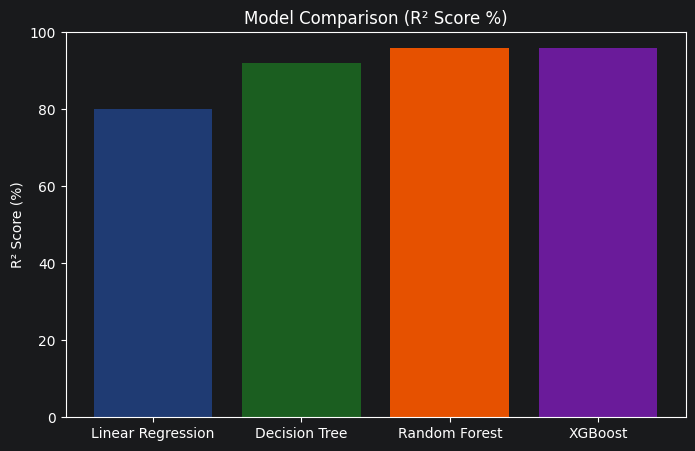

In [208]:
colors = ["#1f3b73", "#1b5e20", "#e65100", "#6a1b9a"]

plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2 Score (%)"], color=colors)

plt.title("Model Comparison (R² Score %)")
plt.ylabel("R² Score (%)")
plt.ylim(0, 100)

plt.show()

From the R² histogram perspective, **Random Forest and XGBoost are the best-performing models**, both achieving consistently high explanatory power, with Random Forest being slightly more stable.



**ACTUAL VS PREDICTED VISUALIZATION**

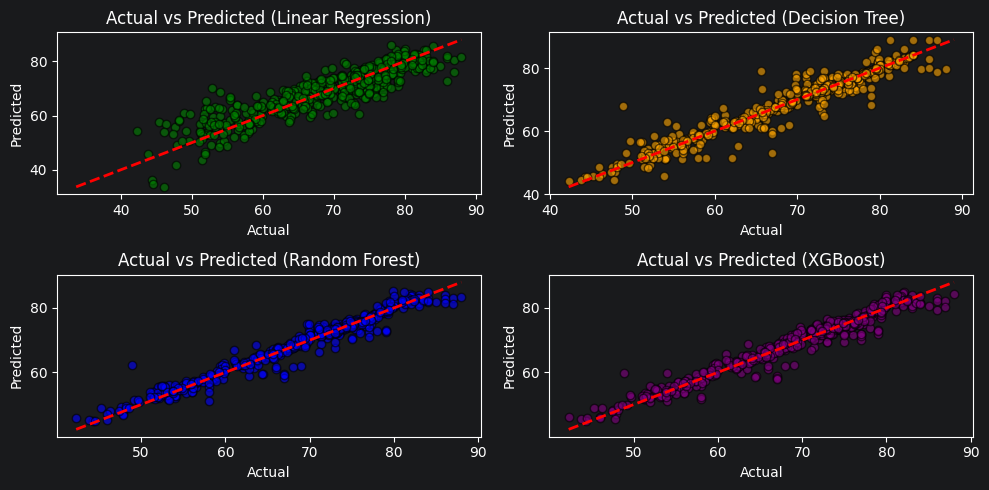

In [209]:
models = [
    ("Linear Regression", lr_pred, "green"),
    ("Decision Tree", dt_pred, "orange"),
    ("Random Forest", rf_pred, "blue"),
    ("XGBoost", xgb_pred, "purple")
]

plt.figure(figsize=(10,5))

for i, (name, pred, color) in enumerate(models, 1):
    plt.subplot(2, 2, i)

    plt.scatter(y_test, pred, color=color, alpha=0.6, edgecolor='black')

    min_val = min(min(y_test), min(pred))
    max_val = max(max(y_test), max(pred))

    plt.plot([min_val, max_val],
             [min_val, max_val],
             color='red',
             linestyle='--',
             linewidth=2)

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted ({name})")

plt.tight_layout()
plt.show()

The scatter plots for all models compare actual values against predicted values to evaluate model performance visually.

- **Linear Regression** shows noticeable scatter away from the ideal diagonal line, indicating higher prediction errors and limited model flexibility.

- **Decision Tree** improves alignment, with points closer to the diagonal, but still shows some scattered predictions due to overfitting on specific samples.

- **Random Forest** shows a strong concentration of points along the diagonal line, indicating high accuracy and strong generalization.

- **XGBoost** also demonstrates tight clustering around the diagonal, with slightly more dispersion than Random Forest in a few regions.

### Conclusion
Overall, **Random Forest and XGBoost provide the best alignment between actual and predicted values**, confirming their superior predictive performance, while **Linear Regression performs the weakest**.

**FEATURE IMPORTANCE**

In [210]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTOP FEATURES:\n", feature_importance.head(10))


TOP FEATURES:
                    Feature  Importance
10                HIV/AIDS    0.597204
1          Adult Mortality    0.206261
13               Schooling    0.084425
7                      BMI    0.025921
12    thinness  1-19 years    0.024763
2            infant deaths    0.017827
3                  Alcohol    0.010432
0                   Status    0.006077
11                     GDP    0.005345
4   percentage expenditure    0.005161


The model is highly influenced by **HIV/AIDS** and **Adult Mortality**, which together contribute the majority of predictive power. Other features have relatively minor impact on the model’s decisions.

**VISUALIZATION OF TOP 5 FEATURES (RANDON FOREST)**

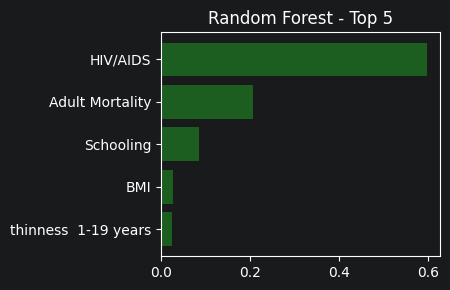

In [214]:
feature_names = X.columns

# -----------------------------
# Random Forest (Top 5)
# -----------------------------
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train, y_train)

rf_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_temp.feature_importances_
}).sort_values("Importance", ascending=False).head(5)


plt.figure(figsize=(12,3))

# Random Forest
plt.subplot(1, 3, 2)
plt.barh(rf_df["Feature"], rf_df["Importance"], color="#1b5e20")
plt.title("Random Forest - Top 5")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

- **HIV/AIDS** is the most dominant feature by a large margin.
- **Adult Mortality** is the second most important factor.
- Other contributing features include:
  - Schooling
  - BMI (Body Mass Index)
  - Thinness (1–19 years)
    - The results indicate that the model is primarily driven by health-related and socio-economic factors.

**SAVE MODEL**

In [212]:
joblib.dump(rf_model, "life_expectancy_model.pkl")

print("\nMODEL SAVED SUCCESSFULLY ✔")


MODEL SAVED SUCCESSFULLY ✔


The best-performing model (Random Forest) is saved so it can be reused for future predictions without retraining.